In [2]:
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [4]:
data = pd.read_csv("loan_data.csv")

data.columns = data.columns.str.strip()

data.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [5]:
print("Shape :", data.shape)

print("\nColumn Names")
print(data.columns)

print("\nData Types")
print(data.dtypes)

data.info()

Shape : (4269, 13)

Column Names
Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='str')

Data Types
loan_id                     int64
no_of_dependents            int64
education                     str
self_employed                 str
income_annum                int64
loan_amount                 int64
loan_term                   int64
cibil_score                 int64
residential_assets_value    int64
commercial_assets_value     int64
luxury_assets_value         int64
bank_asset_value            int64
loan_status                   str
dtype: object
<class 'pandas.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   loan_id    

In [6]:
data.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


In [7]:
data.isnull().sum()

loan_id                     0
no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64

In [8]:
data = data.drop("loan_id", axis=1)

encoder = LabelEncoder()

data["education"] = encoder.fit_transform(data["education"])
data["self_employed"] = encoder.fit_transform(data["self_employed"])
data["loan_status"] = encoder.fit_transform(data["loan_status"])

data.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,0,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,0
1,0,1,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,1
2,3,0,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,1
3,3,0,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,1
4,5,1,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,1


In [9]:
X = data.drop("loan_amount", axis=1)

y = data["loan_amount"]

In [10]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

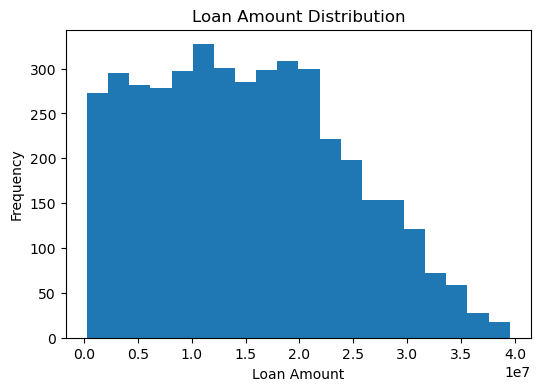

In [11]:
plt.figure(figsize=(6,4))

plt.hist(y, bins=20)

plt.title("Loan Amount Distribution")

plt.xlabel("Loan Amount")

plt.ylabel("Frequency")

plt.show()

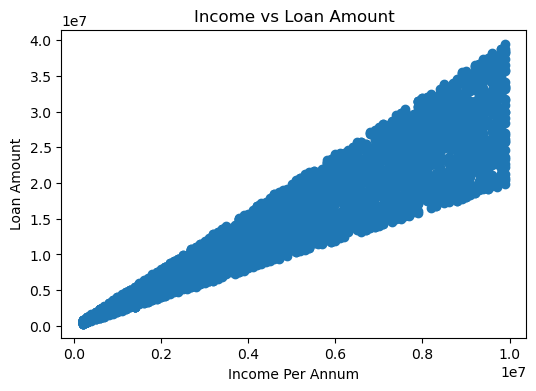

In [12]:
plt.figure(figsize=(6,4))

plt.scatter(data["income_annum"], data["loan_amount"])

plt.xlabel("Income Per Annum")

plt.ylabel("Loan Amount")

plt.title("Income vs Loan Amount")

plt.show()

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data :", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data : (3415, 11)
Testing Data : (854, 11)


In [14]:
linear = LinearRegression()

start = time.time()

linear.fit(X_train, y_train)

linear_time = time.time() - start

linear_pred = linear.predict(X_test)

In [15]:
ridge = Ridge()

start = time.time()

ridge.fit(X_train, y_train)

ridge_time = time.time() - start

ridge_pred = ridge.predict(X_test)

In [16]:
lasso = Lasso()

start = time.time()

lasso.fit(X_train, y_train)

lasso_time = time.time() - start

lasso_pred = lasso.predict(X_test)

In [17]:
elastic = ElasticNet()

start = time.time()

elastic.fit(X_train, y_train)

elastic_time = time.time() - start

elastic_pred = elastic.predict(X_test)

In [18]:
def calculate_metrics(actual, predicted):

    mae = mean_absolute_error(actual, predicted)
    mse = mean_squared_error(actual, predicted)
    rmse = np.sqrt(mse)
    r2 = r2_score(actual, predicted)

    return mae, mse, rmse, r2

In [19]:
linear_result = calculate_metrics(y_test, linear_pred)
ridge_result = calculate_metrics(y_test, ridge_pred)
lasso_result = calculate_metrics(y_test, lasso_pred)
elastic_result = calculate_metrics(y_test, elastic_pred)

performance = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression",
        "Elastic Net"
    ],
    "MAE": [
        linear_result[0],
        ridge_result[0],
        lasso_result[0],
        elastic_result[0]
    ],
    "MSE": [
        linear_result[1],
        ridge_result[1],
        lasso_result[1],
        elastic_result[1]
    ],
    "RMSE": [
        linear_result[2],
        ridge_result[2],
        lasso_result[2],
        elastic_result[2]
    ],
    "R2 Score": [
        linear_result[3],
        ridge_result[3],
        lasso_result[3],
        elastic_result[3]
    ]
})

performance

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,2.598631e+06,1.175502e+13,3.428560e+06,0.853401
1,Ridge Regression,2.598169e+06,1.174876e+13,3.427646e+06,0.853479
2,Lasso Regression,2.598630e+06,1.175502e+13,3.428559e+06,0.853401
3,Elastic Net,3.008482e+06,1.439849e+13,3.794535e+06,0.820434


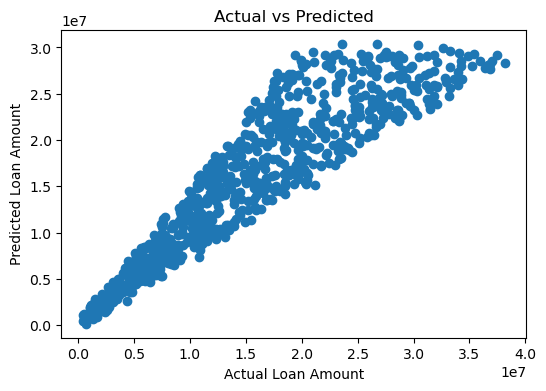

In [20]:
plt.figure(figsize=(6,4))

plt.scatter(y_test, linear_pred)

plt.xlabel("Actual Loan Amount")
plt.ylabel("Predicted Loan Amount")

plt.title("Actual vs Predicted")

plt.show()

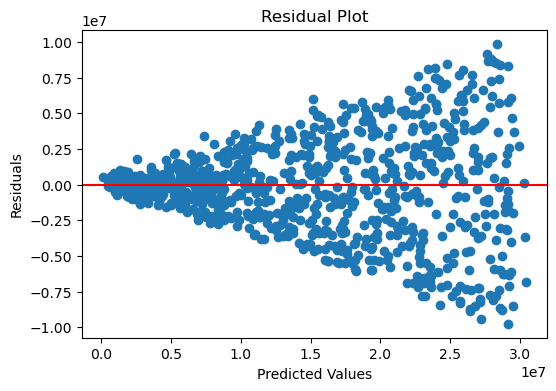

In [21]:
residual = y_test - linear_pred

plt.figure(figsize=(6,4))

plt.scatter(linear_pred, residual)

plt.axhline(0, color="red")

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

In [22]:
time_table = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression",
        "Elastic Net"
    ],
    "Training Time": [
        linear_time,
        ridge_time,
        lasso_time,
        elastic_time
    ]
})

time_table

,Model,Training Time
0,Linear Regression,0.024
1,Ridge Regression,0.008
2,Lasso Regression,0.019
3,Elastic Net,0.005


In [23]:
ridge_parameters = {
    "alpha": [0.01, 0.1, 1, 10, 100]
}

ridge_search = GridSearchCV(
    Ridge(),
    ridge_parameters,
    cv=5,
    scoring="r2"
)

ridge_search.fit(X_train, y_train)

print(ridge_search.best_params_)
print(ridge_search.best_score_)

{'alpha': 1}
0.8631503784114207


In [24]:
lasso_parameters = {
    "alpha": [0.001, 0.01, 0.1, 1, 10]
}

lasso_search = GridSearchCV(
    Lasso(max_iter=10000),
    lasso_parameters,
    cv=5,
    scoring="r2"
)

lasso_search.fit(X_train, y_train)

print(lasso_search.best_params_)
print(lasso_search.best_score_)

{'alpha': 10}
0.8631483155061295


In [25]:
elastic_parameters = {
    "alpha": [0.01, 0.1, 1, 10],
    "l1_ratio": [0.2, 0.5, 0.8]
}

elastic_search = GridSearchCV(
    ElasticNet(max_iter=10000),
    elastic_parameters,
    cv=5,
    scoring="r2"
)

elastic_search.fit(X_train, y_train)

print(elastic_search.best_params_)
print(elastic_search.best_score_)

{'alpha': 0.01, 'l1_ratio': 0.8}
0.8631262882408313


In [26]:
tuning_table = pd.DataFrame({
    "Model": [
        "Ridge Regression",
        "Lasso Regression",
        "Elastic Net"
    ],
    "Search Method": [
        "GridSearchCV",
        "GridSearchCV",
        "GridSearchCV"
    ],
    "Best Parameters": [
        str(ridge_search.best_params_),
        str(lasso_search.best_params_),
        str(elastic_search.best_params_)
    ],
    "Best CV R2": [
        ridge_search.best_score_,
        lasso_search.best_score_,
        elastic_search.best_score_
    ]
})

tuning_table

,Model,Search Method,Best Parameters,Best CV R2
0,Ridge Regression,GridSearchCV,{'alpha': 1},0.863150
1,Lasso Regression,GridSearchCV,{'alpha': 10},0.863148
2,Elastic Net,GridSearchCV,"{'alpha': 0.01, 'l1_ratio': 0.8}",0.863126


In [27]:
linear_cv = cross_val_score(
    LinearRegression(),
    X,
    y,
    cv=5,
    scoring="r2"
)

ridge_cv = cross_val_score(
    Ridge(alpha=ridge_search.best_params_["alpha"]),
    X,
    y,
    cv=5,
    scoring="r2"
)

lasso_cv = cross_val_score(
    Lasso(alpha=lasso_search.best_params_["alpha"], max_iter=10000),
    X,
    y,
    cv=5,
    scoring="r2"
)

elastic_cv = cross_val_score(
    ElasticNet(
        alpha=elastic_search.best_params_["alpha"],
        l1_ratio=elastic_search.best_params_["l1_ratio"],
        max_iter=10000
    ),
    X,
    y,
    cv=5,
    scoring="r2"
)

In [28]:
cv_table = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression",
        "Elastic Net"
    ],
    "R2": [
        linear_cv.mean(),
        ridge_cv.mean(),
        lasso_cv.mean(),
        elastic_cv.mean()
    ]
})

cv_table

,Model,R2
0,Linear Regression,0.861004
1,Ridge Regression,0.861004
2,Lasso Regression,0.861004
3,Elastic Net,0.860974


In [29]:
coefficient_table = pd.DataFrame({
    "Feature": data.drop("loan_amount", axis=1).columns,
    "Linear": linear.coef_,
    "Ridge": ridge.coef_,
    "Lasso": lasso.coef_,
    "Elastic Net": elastic.coef_
})

coefficient_table

,Feature,Linear,Ridge,Lasso,Elastic Net
0,no_of_dependents,-8.666155e+04,-8.663910e+04,-8.666063e+04,-6.453142e+04
1,education,1.941655e+04,1.939012e+04,1.941561e+04,-1.887462e+03
2,self_employed,1.852169e+04,1.857125e+04,1.852076e+04,3.247627e+04
3,income_annum,8.622745e+06,8.593456e+06,8.622726e+06,2.790926e+06
4,loan_term,6.541862e+04,6.526318e+04,6.541700e+04,1.916432e+04
5,cibil_score,-4.290263e+05,-4.282314e+05,-4.290215e+05,-1.135485e+05
6,residential_assets_value,1.575669e+04,1.875031e+04,1.575642e+04,8.459557e+05
7,commercial_assets_value,9.895200e+04,1.016702e+05,9.895147e+04,8.656182e+05
8,luxury_assets_value,-2.024269e+05,-1.847696e+05,-2.024127e+05,2.017624e+06
9,bank_asset_value,-1.287188e+05,-1.208275e+05,-1.287120e+05,1.476201e+06


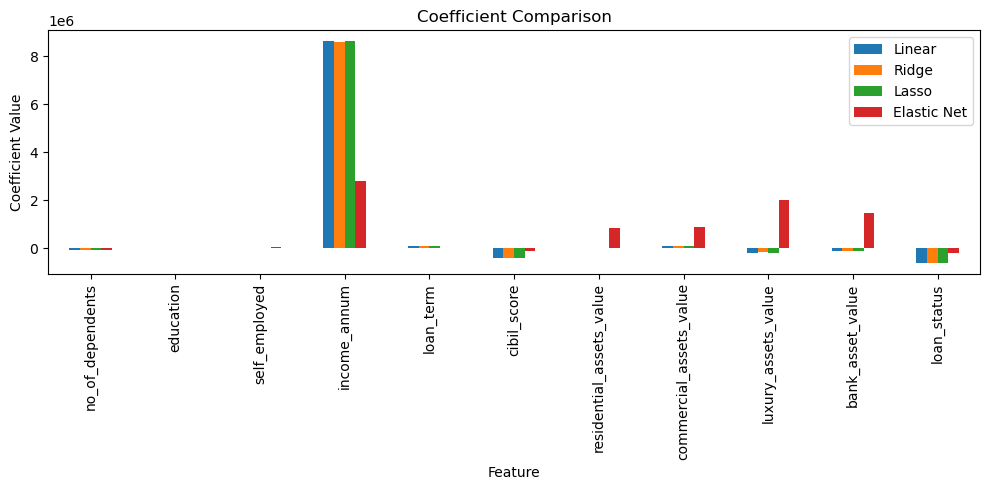

In [30]:
coefficient_table.set_index("Feature").plot(
    kind="bar",
    figsize=(10,5)
)

plt.ylabel("Coefficient Value")
plt.title("Coefficient Comparison")

plt.tight_layout()

plt.show()

In [31]:
training_error = [
    mean_squared_error(y_train, linear.predict(X_train)),
    mean_squared_error(y_train, ridge.predict(X_train)),
    mean_squared_error(y_train, lasso.predict(X_train)),
    mean_squared_error(y_train, elastic.predict(X_train))
]

validation_error = [
    linear_result[1],
    ridge_result[1],
    lasso_result[1],
    elastic_result[1]
]

comparison = pd.DataFrame({
    "Model": [
        "Linear",
        "Ridge",
        "Lasso",
        "Elastic Net"
    ],
    "Training Error": training_error,
    "Validation Error": validation_error
})

comparison

,Model,Training Error,Validation Error
0,Linear,1.114593e+13,1.175502e+13
1,Ridge,1.114601e+13,1.174876e+13
2,Lasso,1.114593e+13,1.175502e+13
3,Elastic Net,1.523658e+13,1.439849e+13


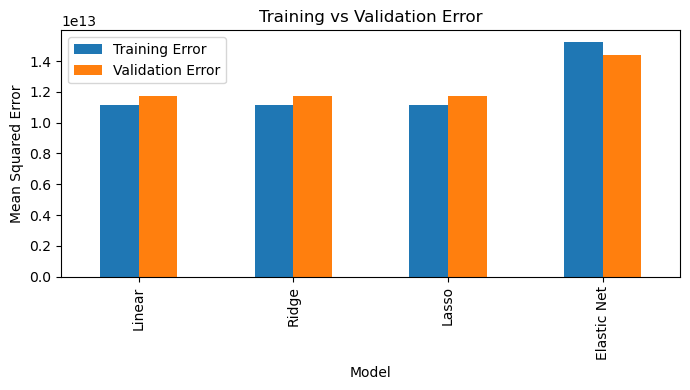

In [32]:
comparison.set_index("Model").plot(
    kind="bar",
    figsize=(7,4)
)

plt.ylabel("Mean Squared Error")
plt.title("Training vs Validation Error")

plt.tight_layout()

plt.show()